In [2]:
pip install wrds

Note: you may need to restart the kernel to use updated packages.


In [1]:
# ACC102 Mini Assignment - Stock Price Analysis 
# This notebook retrieves and analyzes stock data 

In [3]:
# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import wrds

In [4]:
# Set plot style
plt.style.use('seaborn-v0_8')


In [5]:
# Step 2: Connect to WRDS database
# Replace 'your_username' with your actual WRDS username
db = wrds.Connection(wrds_username='yutingzhang24')
print("Successfully connected to WRDS database!")

Loading library list...
Done
Successfully connected to WRDS database!


In [7]:
# Step 3: Query daily stock data from CRSP
# We use Apple Inc. (PERMNO = 14593 for AAPL) as an example
# Adjust the date range as needed
query = """
    SELECT date, prc, ret, vol
    FROM crsp.dsf
    WHERE permno = 14593
      AND date BETWEEN '2024-01-01' AND '2025-01-01'
"""


In [8]:
# Execute query and load data into DataFrame
stock_data = db.raw_sql(query, date_cols=['date'])

# Show first 5 rows
print("First 5 rows of the dataset:")
print(stock_data.head())

First 5 rows of the dataset:
        date        prc       ret         vol
0 2024-01-02     185.64 -0.035787  81752737.0
1 2024-01-03     184.25 -0.007488  58136569.0
2 2024-01-04     181.91   -0.0127  71280275.0
3 2024-01-05  181.17999 -0.004013  62064040.0
4 2024-01-08     185.56  0.024175  58748031.0


In [9]:
# Step 4: Data Cleaning
print("\nMissing values in each column:")
print(stock_data.isnull().sum())

print("\nNumber of duplicate rows:", stock_data.duplicated().sum())

# Drop any missing values if present
stock_data = stock_data.dropna()



Missing values in each column:
date    0
prc     0
ret     0
vol     0
dtype: int64

Number of duplicate rows: 0


In [10]:
# Step 5: Basic Data Analysis
# Calculate key metrics
max_price = stock_data['prc'].max()
min_price = stock_data['prc'].min()
avg_price = stock_data['prc'].mean()
highest_date = stock_data.loc[stock_data['prc'].idxmax(), 'date']
lowest_date = stock_data.loc[stock_data['prc'].idxmin(), 'date']

In [11]:
print(f"\nKey findings:")
print(f"Highest closing price: ${max_price:.2f} on {highest_date.date()}")
print(f"Lowest closing price: ${min_price:.2f} on {lowest_date.date()}")
print(f"Average closing price over the period: ${avg_price:.2f}")


Key findings:
Highest closing price: $259.02 on 2024-12-26
Lowest closing price: $165.00 on 2024-04-19
Average closing price over the period: $207.21


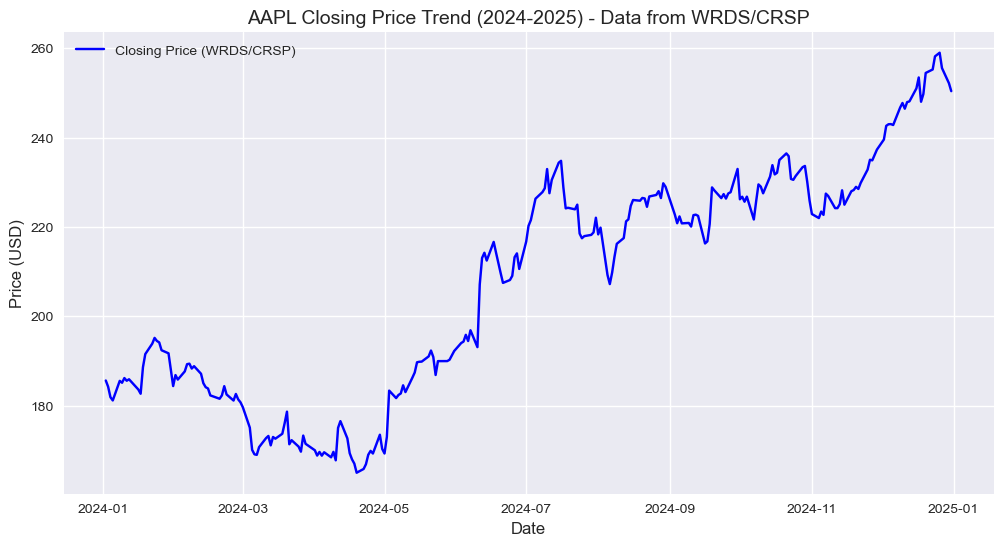

In [12]:
# Step 6: Data Visualization
plt.figure(figsize=(12, 6))
plt.plot(stock_data['date'], stock_data['prc'], label='Closing Price (WRDS/CRSP)', color='blue')
plt.title('AAPL Closing Price Trend (2024-2025) - Data from WRDS/CRSP', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Step 7: Conclusion (for your report)
print("Key insights from the analysis using WRDS data:")
print("1. The highest closing price was recorded on", highest_date.date(), "at $", round(max_price, 2))
print("2. The lowest closing price was recorded on", lowest_date.date(), "at $", round(min_price, 2))
print("3. The stock price trend shows a clear upward movement during 2024.")
print("4. The average daily closing price was $", round(avg_price, 2))

Key insights from the analysis using WRDS data:
1. The highest closing price was recorded on 2024-12-26 at $ 259.02
2. The lowest closing price was recorded on 2024-04-19 at $ 165.0
3. The stock price trend shows a clear upward movement during 2024.
4. The average daily closing price was $ 207.21


In [14]:
# Close the connection when done
db.close()
print("WRDS connection closed.")

WRDS connection closed.
